In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../notebooks/data/spam.csv", encoding="latin1")

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [7]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [8]:
df.sample(5)

,v1,v2
1271,ham,If you still havent collected the dough pls le...
695,ham,Good. Good job. I like entrepreneurs
3691,ham,No i am not having not any movies in my laptop
3241,ham,Good Morning my Dear........... Have a great &...
2381,ham,Best line said in Love: . \I will wait till th...


In [9]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1362,ham,What does the dance river do?
1985,ham,The length is e same but e top shorter n i got...
1411,ham,somewhere out there beneath the pale moon ligh...
4972,ham,Oops I was in the shower when u called. Hey a ...
3082,ham,K..k:)how about your training process?


In [10]:
df["target"].value_counts()

target
ham     4825
spam     747
Name: count, dtype: int64

In [11]:
df.tail()

,target,text
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [12]:
df.shape

(5572, 2)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   target  5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [14]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(403)

In [16]:
df = df.drop_duplicates(keep='first').reset_index(drop=True)

In [17]:
df.shape

(5169, 2)

In [18]:
df["target"].value_counts(normalize=True) * 100

target
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Email Category Distribution')

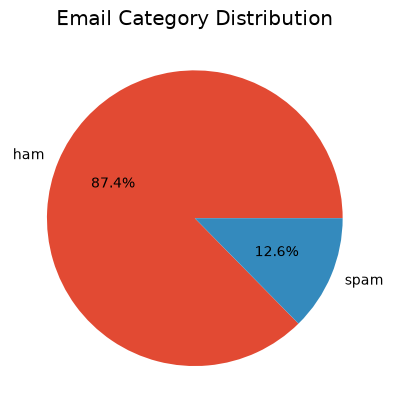

In [19]:
df["target"].value_counts().plot(
    kind="pie",
    autopct = "%1.1f%%"
)
plt.title("Email Category Distribution")

In [20]:
df["num_characters"] = df["text"].apply(len)

In [21]:
df.head(2)

,target,text,num_characters
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29


In [22]:
df["num_characters"].describe()

count    5169.000000
mean       78.977945
std        58.236293
min         2.000000
25%        36.000000
50%        60.000000
75%       117.000000
max       910.000000
Name: num_characters, dtype: float64

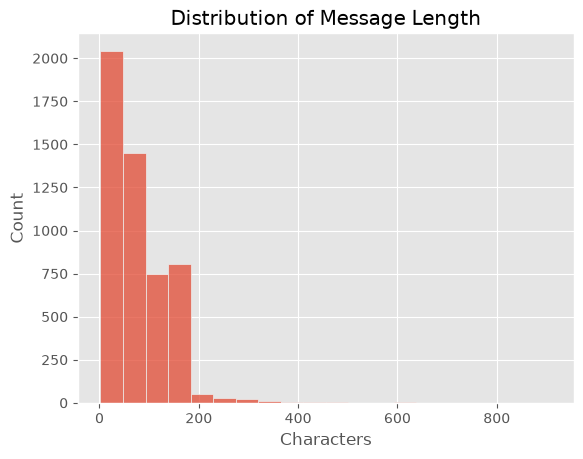

In [23]:
sns.histplot(df["num_characters"], bins=20)
plt.title("Distribution of Message Length")
plt.xlabel("Characters")
plt.show()

In [24]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [25]:
nltk.download('punkt_tab')
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [26]:
df.head()

,target,text,num_characters,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15


In [27]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [28]:
df.head(3)

,target,text,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2


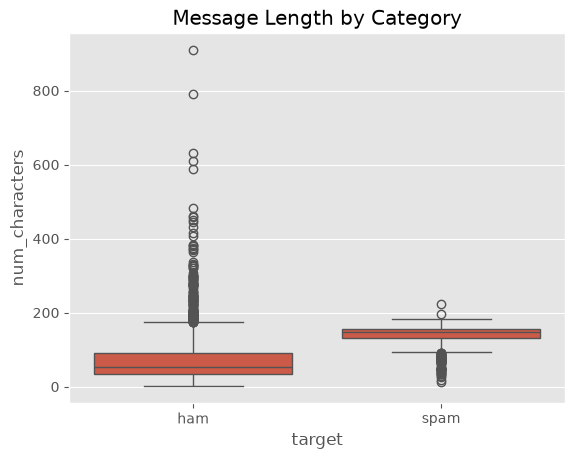

In [29]:
sns.boxplot(data=df, x="target", y="num_characters")
plt.title("Message Length by Category")
plt.show()

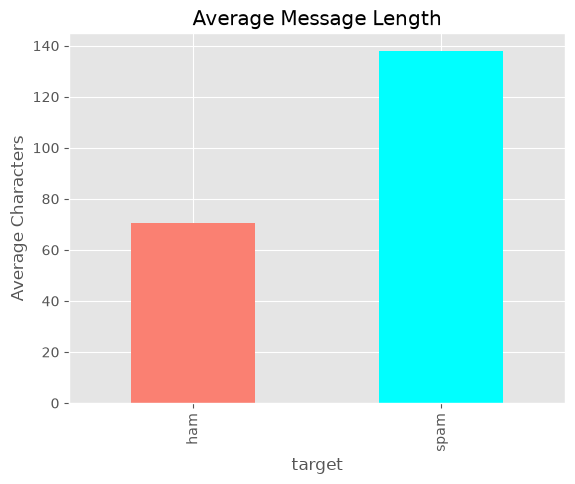

In [30]:
df.groupby("target")["num_characters"].mean().plot(
    kind="bar",
    color=["salmon", "cyan"]
)
plt.title("Average Message Length")
plt.ylabel("Average Characters")
plt.show()

In [31]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [32]:
df.head(2)

,target,text,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2


In [33]:
df["target"] = df["target"].map({
    "ham" : 0,
    "spam" : 1
})

In [34]:
df.head(5)

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [35]:
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [36]:
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


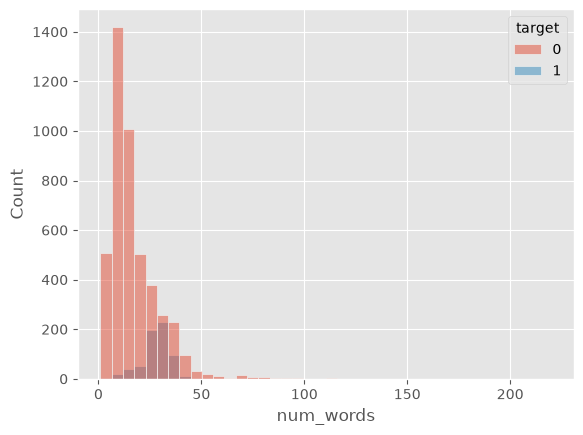

In [37]:
sns.histplot(data=df, x="num_words", hue="target", bins=40)
plt.show()

In [38]:
df.groupby("target")["num_words"].mean()

target
0    17.123782
1    27.667688
Name: num_words, dtype: float64

In [39]:
df.nsmallest(5, "num_characters")

,target,text,num_characters,num_words,num_sentences
1858,0,Ok,2,1,1
256,0,Yup,3,1,1
1560,0,645,3,1,1
2096,0,Ok.,3,2,1
3191,0,:),3,2,1


In [40]:
df.nlargest(5, "num_characters")

,target,text,num_characters,num_words,num_sentences
1059,0,For me the love should start with attraction.i...,910,175,1
1800,0,The last thing i ever wanted to do was hurt yo...,790,196,10
2333,0,Indians r poor but India is not a poor country...,632,161,11
1528,0,How to Make a girl Happy? It's not at all diff...,611,220,38
2075,0,Sad story of a Man - Last week was my b'day. M...,588,154,18


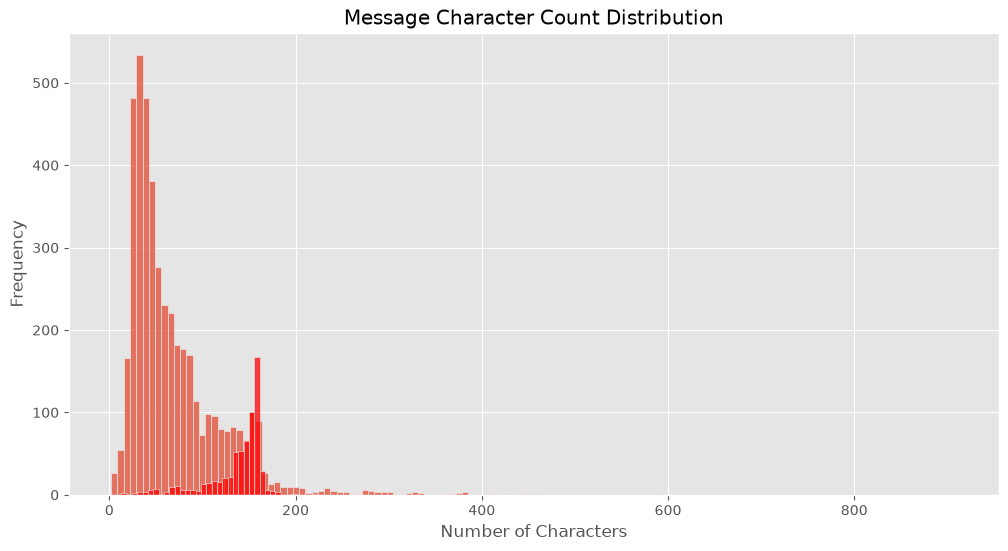

In [41]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')
plt.title("Message Character Count Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

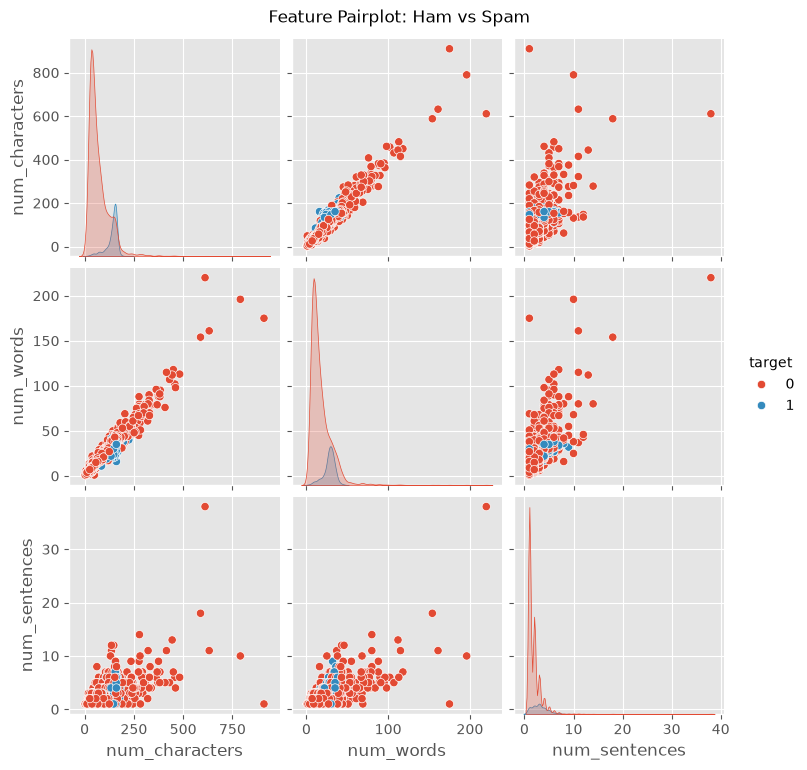

In [42]:
sns.pairplot(df,hue='target')
plt.suptitle("Feature Pairplot: Ham vs Spam", y=1.02)
plt.show()

In [43]:
df.head(3)

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2


In [44]:
col = ["target", "num_characters", "num_words", "num_sentences"]

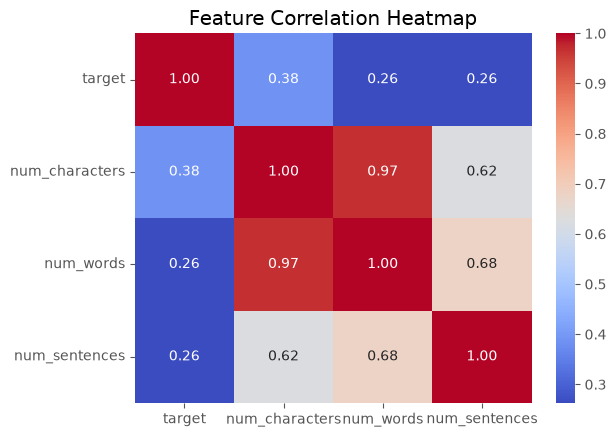

In [45]:
sns.heatmap(df[col].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [46]:
import string
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def transform_text(text):
    # lowercase
    text = text.lower()

    # tokenize
    text = nltk.word_tokenize(text)

    # remove special characters/punctuation
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    # remove stopwords
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # lemmatization 
    for i in text:
        y.append(lemmatizer.lemmatize(i))

    return " ".join(y)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [48]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...


True

In [49]:
check = transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")
check

'gon na home soon want talk stuff anymore tonight k cried enough today'

In [50]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think go usf life around though


In [51]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

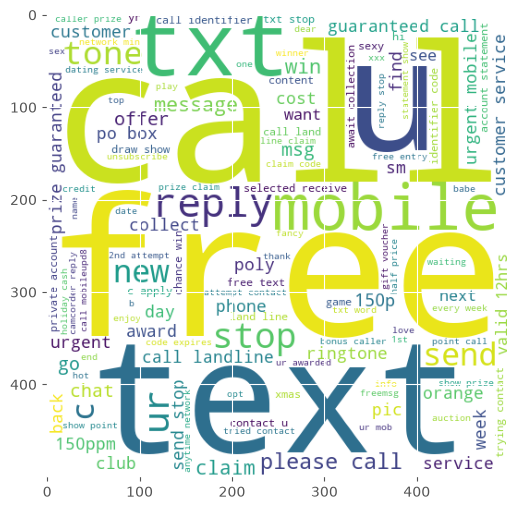

In [52]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

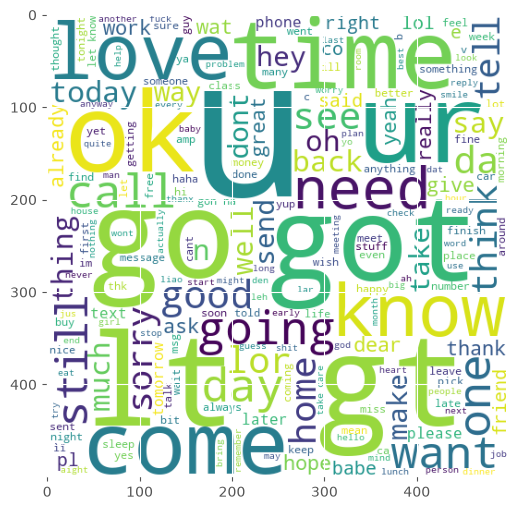

In [53]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [54]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think go usf life around though


In [55]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [56]:
len(spam_corpus)

9939

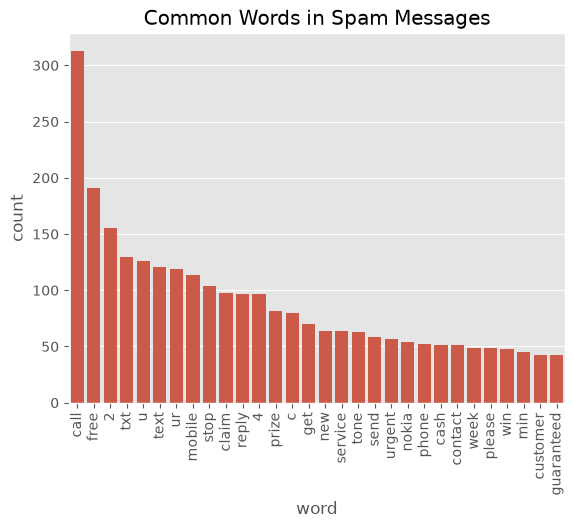

In [ ]:
from collections import Counter
data_spam = pd.DataFrame(
    Counter(spam_corpus).most_common(30),
    columns=["word", "count"]
)
sns.barplot(data=data_spam, x="word", y="count")
plt.xticks(rotation="vertical")
plt.title("Common Words in Spam Messages")
plt.show()

In [59]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [60]:
len(ham_corpus)

35404

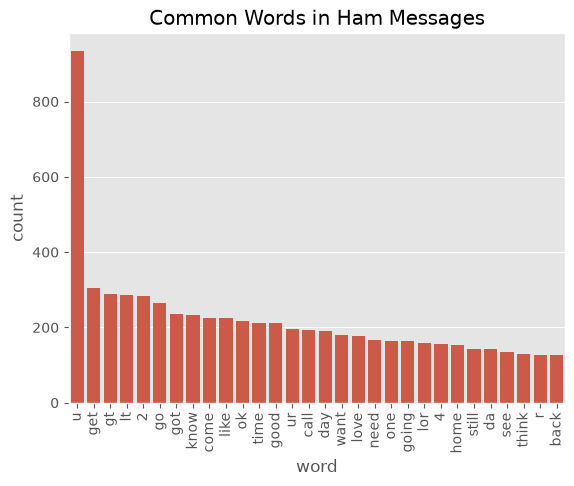

In [61]:
data_ham = pd.DataFrame(
    Counter(ham_corpus).most_common(30),
    columns=["word", "count"]
)

sns.barplot(data=data_ham, x="word", y="count")
plt.xticks(rotation="vertical")
plt.title("Common Words in Ham Messages")
plt.show()

In [63]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences',
       'transformed_text'],
      dtype='str')

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, classification_report)

In [65]:
X = df['transformed_text']

In [66]:
y = df['target']

In [67]:
X

0       go jurong point crazy available bugis n great ...
1                                 ok lar joking wif u oni
2       free entry 2 wkly comp win fa cup final tkts 2...
3                     u dun say early hor u c already say
4                     nah think go usf life around though
                              ...                        
5164    2nd time tried 2 contact u pound prize 2 claim...
5165                            b going esplanade fr home
5166                                 pity mood suggestion
5167    guy bitching acted like interested buying some...
5168                                       rofl true name
Name: transformed_text, Length: 5169, dtype: str

In [68]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5164    1
5165    0
5166    0
5167    0
5168    0
Name: target, Length: 5169, dtype: int64

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [70]:
df.shape

(5169, 6)

In [71]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [72]:
from sklearn.model_selection import RandomizedSearchCV
models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    "LinearSVC": LinearSVC(
        class_weight="balanced"
    )
}

param_distributions = {
    "MultinomialNB": {
        "alpha": [0.1, 0.5, 1, 2, 5]
    },

    "LogisticRegression": {
        "C": [0.01, 0.1, 1, 10, 100]
    },

    "LinearSVC": {
        "C": [0.01, 0.1, 1, 10]
    }
}

best_models = {}
tuning_results = []

best_models = {}
tuning_results = []

for name, model in models.items():
    print(f"\nTuning {name}...")
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[name],
        n_iter=10,
        scoring="f1",
        random_state=42,
        cv=5,
        n_jobs=-1
    )

    random_search.fit(X_train_vec, y_train)

    best_model = random_search.best_estimator_
    best_models[name] = best_model

    preds = best_model.predict(X_test_vec)

    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test_vec)[:, 1]

    elif hasattr(best_model, "decision_function"):
        y_prob = best_model.decision_function(X_test_vec)

    else:
        y_prob = preds

    roc_auc = roc_auc_score(y_test, y_prob)

    tuning_results.append({
        "model": name,
        "best_params": random_search.best_params_,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc
    })


tuning_results_df = pd.DataFrame(tuning_results)

print("\nTuned Model Results:")
print(tuning_results_df.to_string(index=False))


Tuning MultinomialNB...

Tuning LogisticRegression...

Tuning LinearSVC...

Tuned Model Results:
             model    best_params  accuracy  precision   recall       f1  roc_auc
     MultinomialNB {'alpha': 0.1}  0.973888   0.956140 0.832061 0.889796 0.989074
LogisticRegression      {'C': 10}  0.977756   0.921875 0.900763 0.911197 0.991314
         LinearSVC       {'C': 1}  0.978723   0.929134 0.900763 0.914729 0.989839


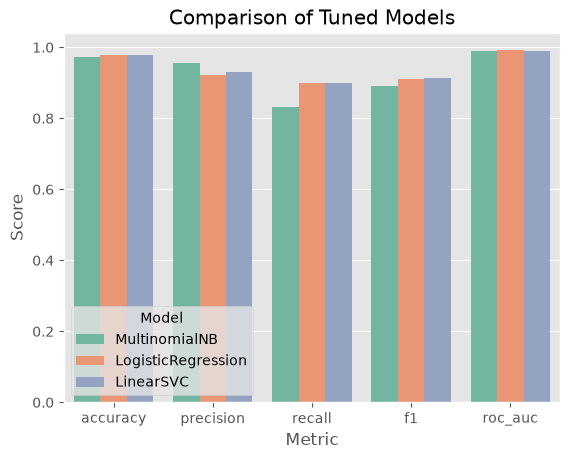

In [73]:
metrics_df = tuning_results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="Metric",
    value_name="Score"
)
sns.barplot(
    data=metrics_df,
    x="Metric",
    y="Score",
    hue="model",
    palette="Set2"
)
plt.title("Comparison of Tuned Models")
plt.ylabel("Score")
plt.legend(title="Model", loc="lower left")
plt.show()

In [74]:
best_model_name = tuning_results_df.sort_values("f1", ascending=False).iloc[0]["model"]
best_model = best_models[best_model_name]

In [75]:
best_model

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo 

In [76]:
preds = best_model.predict(X_test_vec)

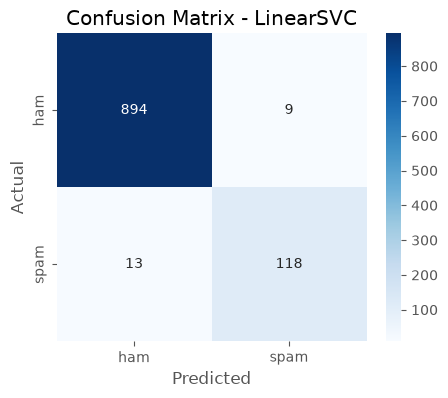

In [77]:
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [78]:
print(classification_report(y_test, preds, target_names=["ham", "spam"]))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.93      0.90      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [79]:
examples = [
    "Congratulations! You have won a FREE vacation to Dubai. Call now!",
    "URGENT! Your bank account has been suspended. Verify immediately.",
    "You have been selected to receive a $500 Amazon gift card",
    "Claim your lottery prize by clicking the link below",
    "XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or click here>> http://wap. xxxmobilemovieclub.com?n=QJKGIGHJJGCBL",
]

example_vec = tfidf.transform(examples)
predictions = best_model.predict(example_vec)

for text, pred in zip(examples, predictions):
    print(f"{text}\nPrediction: {'Spam' if pred==1 else 'Ham'}\n")

Congratulations! You have won a FREE vacation to Dubai. Call now!
Prediction: Spam

URGENT! Your bank account has been suspended. Verify immediately.
Prediction: Ham

You have been selected to receive a $500 Amazon gift card
Prediction: Spam

Claim your lottery prize by clicking the link below
Prediction: Spam

XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or click here>> http://wap. xxxmobilemovieclub.com?n=QJKGIGHJJGCBL
Prediction: Spam

